In [1]:
import sys
import numpy as np
from PIL import Image, ImageDraw
import cv2
import pylab as pl

# Optional: display plots inline
%matplotlib inline


In [4]:
# Manually set the path to your image
inputfile = "C:\\Users\\Meet\\OneDrive\\LSST-TVSSC.github.io\\subgroups\\images\\andrej.jpg"  # Change this to your actual image file path
print(f"Selected file: {inputfile}")


Selected file: C:\Users\Meet\OneDrive\LSST-TVSSC.github.io\subgroups\images\andrej.jpg


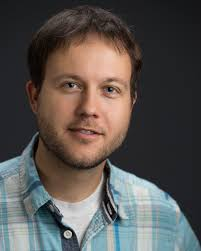

Circular cropped image saved as: C:\Users\Meet\OneDrive\LSST-TVSSC.github.io\subgroups\images\andrej_circularcropped.png


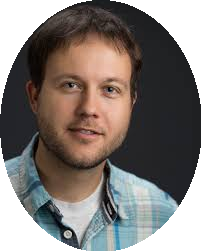

In [5]:
img = Image.open(inputfile)
display(img)

h, w = img.size

# Create luminous mask
lum_img = Image.new('L', [h, w], 0)
draw = ImageDraw.Draw(lum_img)
draw.pieslice([(0, 0), (h, w)], 0, 360, fill=255)

img_arr = np.array(img)
lum_img_arr = np.array(lum_img)

# Combine alpha channel
final_img_arr = np.dstack((img_arr, lum_img_arr))
final = Image.fromarray(final_img_arr)

circular_outname = inputfile.rsplit(".", 1)[0] + "_circularcropped.png"
final.save(circular_outname, "PNG")
print(f"Circular cropped image saved as: {circular_outname}")
display(final)


In [ ]:
import ipywidgets as widgets
from ipywidgets import interact

def cartoonize(smoothness=3):
    img_cv = cv2.imread(inputfile)
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

    # Edge detection
    edges = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                  cv2.THRESH_BINARY, 9, 9)
    edges2 = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                   cv2.THRESH_BINARY, smoothness, smoothness)

    # Bilateral filter
    color = cv2.bilateralFilter(gray, 15, 50, 50)

    def adjust_gamma(image, gamma=1.0):
        invGamma = 1.0 / gamma
        table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(256)]).astype("uint8")
        return cv2.LUT(image, table)

    adjusted = adjust_gamma(color, gamma=1)

    cartoon = cv2.bitwise_and(adjusted, adjusted, mask=edges2)
    cartoon = cv2.bitwise_and(cartoon, cartoon, mask=edges)
    cartoon = cv2.bitwise_and(cartoon, adjusted, mask=edges2)

    pl.figure(figsize=(6,6))
    pl.imshow(cartoon, cmap="gray")
    pl.axis("off")
    pl.show()

    outname = inputfile.rsplit(".", 1)[0] + "_avatar.png"
    cv2.imwrite(outname, cartoon)
    print(f"Cartoon image saved as: {outname}")

interact(cartoonize, smoothness=widgets.IntSlider(min=3, max=15, step=2, value=3))


interactive(children=(IntSlider(value=3, description='smoothness', max=15, min=3, step=2), Output()), _dom_cla…

<function __main__.cartoonize(smoothness=3)>

First image: C:\Users\Meet\OneDrive\LSST-TVSSC.github.io\subgroups\images\andrej_avatar.png
Second image: C:\Users\Meet\OneDrive\LSST-TVSSC.github.io\subgroups\images\andrej_circularcropped.png
Merged image saved as: merged_image.png


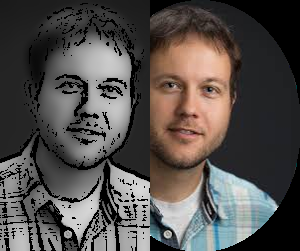

In [1]:
from PIL import Image
from IPython.display import display

# --- Manually set paths here ---
img1_path = "C:\\Users\\Meet\\OneDrive\\LSST-TVSSC.github.io\\subgroups\\images\\andrej_avatar.png"  # Change this to your first image
img2_path = "C:\\Users\\Meet\\OneDrive\\LSST-TVSSC.github.io\\subgroups\\images\\andrej_circularcropped.png" # Change this to your second image

print(f"First image: {img1_path}")
print(f"Second image: {img2_path}")

def merge_images(img1_path, img2_path):
    image1 = Image.open(img1_path)
    image2 = Image.open(img2_path)

    # Resize first image to match second
    image1 = image1.resize(image2.size)
    image1_size = image1.size

    # Crop left 75% of first image
    box1 = (0, 0, int(image1_size[0] * 0.75), image1_size[1])
    image1 = image1.crop(box1)

    # Crop right 75% of second image
    box2 = (int(image1_size[0] * 0.25), 0, image1_size[0], image1_size[1])
    image2 = image2.crop(box2)

    # Resize second image to match first
    image2 = image2.resize(image1.size)

    # Create new merged image
    new_image = Image.new('RGB', (image1.size[0] * 2, image1.size[1]), (250, 250, 250))
    new_image.paste(image1, (0, 0))
    new_image.paste(image2, (image1.size[0], 0))

    merged_outname = "merged_image.png"
    new_image.save(merged_outname, "PNG")
    print(f"Merged image saved as: {merged_outname}")
    display(new_image)

# Call function directly with your paths
merge_images(img1_path, img2_path)
